# H3 — Animal Symbolism: Statistical Tests & Models 3–4

**Hypothesis (H3 main):** In religious artworks, animal symbolism differentiates the degree of gender W−C equalization: purity-coded animals (e.g. lamb, dove) are associated with stronger competence elevation for female figures, while power-coded animals (e.g. horse, eagle) are associated with greater residual asymmetry.

**H3(a):** The Gender × ReligiousTheme attenuation of W−C asymmetry is stronger in artworks where purity-coded animals are present than in artworks without them or with power-coded animals.

**H3(b):** The degree of gender equalization in religious artworks varies systematically across animal symbolic clusters, with purity symbols producing the strongest equalization and power symbols the weakest.

**Depends on:** Notebook 05 (H3 clustering) which assigned `animal_cluster` to the `artwork` table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
import re
import warnings
warnings.filterwarnings('ignore')

# ── Style (consistent with prior notebooks) ──
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS     = {"Male": "#6dc985", "Female": "#4f2478"}
CTX_COLORS = {"religious": "#660033", "secular": "#B8C4BB"}
CLU_COLORS = {"purity": "#4A90D9", "power": "#D94A4A", "other": "#888888", "none": "#CCCCCC", "mixed": "#E8A838"}
DPI = 150
from pathlib import Path
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*x.var() + (ny-1)*y.var()) / (nx+ny-2))
    return (x.mean() - y.mean()) / sp if sp > 0 else 0.0

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Load data directly from SQLite ──
import sqlite3

DB_PATH = '/home/agrupa-lab/agrupa/agrupa.sqlite'
conn = sqlite3.connect(DB_PATH)

# Load figures with artwork-level attributes
df = pd.read_sql("""
    SELECT f.*,
           a.is_religious,
           a.is_fauna,
           a.century,
           a.animal_cluster
    FROM figures_m f
    JOIN artwork a ON f.cat_no = a.cat_no
""", conn)
conn.close()

# Filter to Male/Female, create binary indicators
dfa = df[df["gender"].isin(["Male", "Female"])].copy()
dfa["female"]    = (dfa["gender"]  == "Female").astype(int)
dfa["religious"]  = dfa["is_religious"].astype(int)
dfa["context"]    = dfa["is_religious"].map({1: "religious", 0: "secular"})

# Parse century for controls
def parse_century(val):
    if pd.isna(val): return None
    m = re.match(r"(\d+)", str(val).strip())
    return int(m.group(1)) if m else None

dfa["century_num"] = dfa["century"].apply(parse_century)

def century_bin(c):
    if pd.isna(c): return None
    if c <= 15: return "≤15th"
    elif c == 16: return "16th"
    elif c == 17: return "17th"
    elif c == 18: return "18th"
    else: return "19th+"

dfa["century_bin"] = dfa["century_num"].apply(century_bin)

# Fill missing animal_cluster (artworks without fauna)
dfa["animal_cluster"] = dfa["animal_cluster"].fillna("none")

# Binary indicators for clusters
dfa["is_purity"] = (dfa["animal_cluster"] == "purity").astype(int)
dfa["is_power"]  = (dfa["animal_cluster"] == "power").astype(int)

print(f"Analysis set: {len(dfa):,} figures")
print(f"  Religious: {dfa['religious'].sum():,}  |  Secular: {(1-dfa['religious']).sum():,}")
print(f"  Male: {(dfa['gender']=='Male').sum():>8,}  |  Female: {(dfa['gender']=='Female').sum():>6,}")
print(f"\nAnimal cluster distribution:")
print(dfa["animal_cluster"].value_counts())
print(f"\n2×2×cluster cell counts:")
print(dfa.groupby(["context", "gender", "animal_cluster"]).size().unstack(fill_value=0))

Analysis set: 18,761 figures
  Religious: 7,750  |  Secular: 11,011
  Male:   12,005  |  Female:  6,756

Animal cluster distribution:
animal_cluster
none      10307
other      3546
power      2845
purity     1578
mixed       485
Name: count, dtype: int64

2×2×cluster cell counts:
animal_cluster    mixed  none  other  power  purity
context   gender                                   
religious Female     61  1683    316    230     393
          Male      111  3160    583    576     637
secular   Female    105  2230    985    532     221
          Male      208  3234   1662   1507     327


---
## 1. Descriptive: Asymmetry by Cluster × Context × Gender

In [3]:
# ── 1a. Full descriptive table ──
desc = dfa.groupby(["animal_cluster", "context", "gender"]).agg(
    n=("cat_no", "count"),
    warmth_mean=("dirmean_Warmth", "mean"),
    competence_mean=("dirmean_Competence", "mean"),
    asymmetry_mean=("asymmetry", "mean"),
    asymmetry_sd=("asymmetry", "std"),
).round(4)

print("=" * 80)
print("Descriptive Statistics: Cluster × Context × Gender")
print("=" * 80)
display(desc)

Descriptive Statistics: Cluster × Context × Gender


n  warmth_mean  competence_mean  \
animal_cluster context   gender                                       
mixed          religious Female    61       0.5968           0.6259   
                         Male     111       0.3997           0.6257   
               secular   Female   105       0.4708           0.5148   
                         Male     208       0.3247           0.6438   
none           religious Female  1683       0.5273           0.5361   
                         Male    3160       0.4035           0.5155   
               secular   Female  2230       0.4317           0.5026   
                         Male    3234       0.3670           0.6403   
other          religious Female   316       0.5453           0.5197   
                         Male     583       0.4272           0.5439   
               secular   Female   985       0.4282           0.4716   
                         Male    1662       0.2481           0.5684   
power          religious Female   230       0.4961           0.4838   
                         Male     576       0.3590           0.5899   
               secular   Female   532       0.4446           0.4995   
                         Male    1507       0.2883           0.6466   
purity         religious Female   393       0.5779           0.5134   
                         Male     637       0.4562           0.5576   
               secular   Female   221       0.5063           0.3966   
                         Male     327       0.3480           0.5222   

                                 asymmetry_mean  asymmetry_sd  
animal_cluster context   gender                                
mixed          religious Female         -0.0247        0.4474  
                         Male           -0.2233        0.4949  
               secular   Female         -0.0367        0.4615  
                         Male           -0.3311        0.4739  
none           religious Female         -0.0185        0.4858  
                         Male           -0.1218        0.5546  
               secular   Female         -0.0852        0.5116  
                         Male           -0.2808        0.5217  
other          religious Female          0.0226        0.5059  
                         Male           -0.1302        0.5796  
               secular   Female         -0.0666        0.5546  
                         Male           -0.3278        0.5847  
power          religious Female         -0.0097        0.5014  
                         Male           -0.2389        0.5199  
               secular   Female         -0.0599        0.5016  
                         Male           -0.3648        0.5202  
purity         religious Female          0.0557        0.4793  
                         Male           -0.0976        0.5457  
               secular   Female          0.0941        0.5577  
                         Male           -0.1875        0.4747

In [4]:
# ── 1b. Gender gap (F−M) in asymmetry by cluster × context ──
print("=" * 70)
print("Gender Gap in Asymmetry (Female − Male) by Cluster × Context")
print("=" * 70)

gap_rows = []
for cluster in ["purity", "power", "other", "mixed", "none"]:
    for ctx in ["religious", "secular"]:
        m = dfa[(dfa["animal_cluster"]==cluster) & (dfa["context"]==ctx) & (dfa["gender"]=="Male")]["asymmetry"].dropna()
        f = dfa[(dfa["animal_cluster"]==cluster) & (dfa["context"]==ctx) & (dfa["gender"]=="Female")]["asymmetry"].dropna()
        if len(m) > 5 and len(f) > 5:
            gap = f.mean() - m.mean()
            d = cohens_d(f, m)
            gap_rows.append({
                "Cluster": cluster, "Context": ctx,
                "n_F": len(f), "n_M": len(m),
                "Mean_F": round(f.mean(), 4), "Mean_M": round(m.mean(), 4),
                "Gap (F−M)": round(gap, 4), "Cohen's d": round(d, 4)
            })

df_gaps = pd.DataFrame(gap_rows)
display(df_gaps)

# The key comparison for H3:
print("\n── H3 Key Comparison ──")
for cluster in ["purity", "power"]:
    rel = df_gaps[(df_gaps["Cluster"]==cluster) & (df_gaps["Context"]=="religious")]
    sec = df_gaps[(df_gaps["Cluster"]==cluster) & (df_gaps["Context"]=="secular")]
    if len(rel) and len(sec):
        gap_rel = rel["Gap (F−M)"].values[0]
        gap_sec = sec["Gap (F−M)"].values[0]
        print(f"  {cluster.upper():8s} | Religious gap: {gap_rel:+.4f}  Secular gap: {gap_sec:+.4f}  Attenuation: {gap_rel - gap_sec:+.4f}")

Gender Gap in Asymmetry (Female − Male) by Cluster × Context


,Cluster,Context,n_F,n_M,Mean_F,Mean_M,Gap (F−M),Cohen's d
0,purity,religious,383,610,0.0557,-0.0976,0.1533,0.2942
1,purity,secular,203,301,0.0941,-0.1875,0.2816,0.5524
2,power,religious,216,549,-0.0097,-0.2389,0.2291,0.4451
3,power,secular,511,1455,-0.0599,-0.3648,0.3049,0.5916
4,other,religious,304,548,0.0226,-0.1302,0.1528,0.2756
5,other,secular,923,1533,-0.0666,-0.3278,0.2612,0.4555
6,mixed,religious,57,108,-0.0247,-0.2233,0.1985,0.4144
7,mixed,secular,100,199,-0.0367,-0.3311,0.2943,0.6265
8,none,religious,1630,2990,-0.0185,-0.1218,0.1032,0.1943
9,none,secular,2113,3040,-0.0852,-0.2808,0.1956,0.3779



── H3 Key Comparison ──
  PURITY   | Religious gap: +0.1533  Secular gap: +0.2816  Attenuation: -0.1283
  POWER    | Religious gap: +0.2291  Secular gap: +0.3049  Attenuation: -0.0758


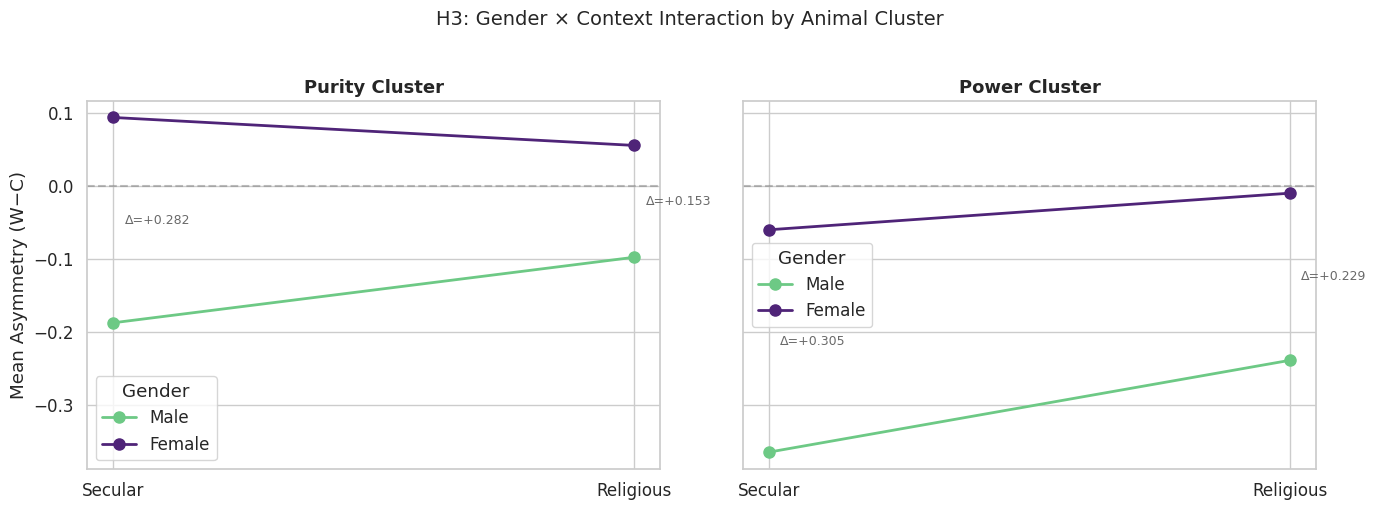

In [5]:
# ── 1c. Interaction plot: Purity vs Power clusters ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, cluster in enumerate(["purity", "power"]):
    data = dfa[dfa["animal_cluster"] == cluster]
    
    means = data.groupby(["context", "gender"])["asymmetry"].mean().unstack()
    
    for g, color in COLORS.items():
        if g in means.columns:
            vals = [means.loc[ctx, g] if ctx in means.index else np.nan 
                    for ctx in ["secular", "religious"]]
            axes[i].plot(["Secular", "Religious"], vals, 
                        "o-", color=color, linewidth=2, markersize=8, label=g)
    
    axes[i].set_title(f"{cluster.title()} Cluster", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Mean Asymmetry (W−C)" if i == 0 else "")
    axes[i].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[i].legend(title="Gender")
    
    # Annotate gender gaps
    for j, ctx in enumerate(["secular", "religious"]):
        if "Male" in means.columns and "Female" in means.columns and ctx in means.index:
            gap = means.loc[ctx, "Female"] - means.loc[ctx, "Male"]
            mid = (means.loc[ctx, "Female"] + means.loc[ctx, "Male"]) / 2
            axes[i].annotate(f"Δ={gap:+.3f}", xy=(j, mid), fontsize=9, 
                           ha="left", va="center", xytext=(8, 0),
                           textcoords="offset points", color="dimgray")

plt.suptitle("H3: Gender × Context Interaction by Animal Cluster", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "h3_interaction_purity_vs_power.png", dpi=DPI, bbox_inches="tight")
plt.show()

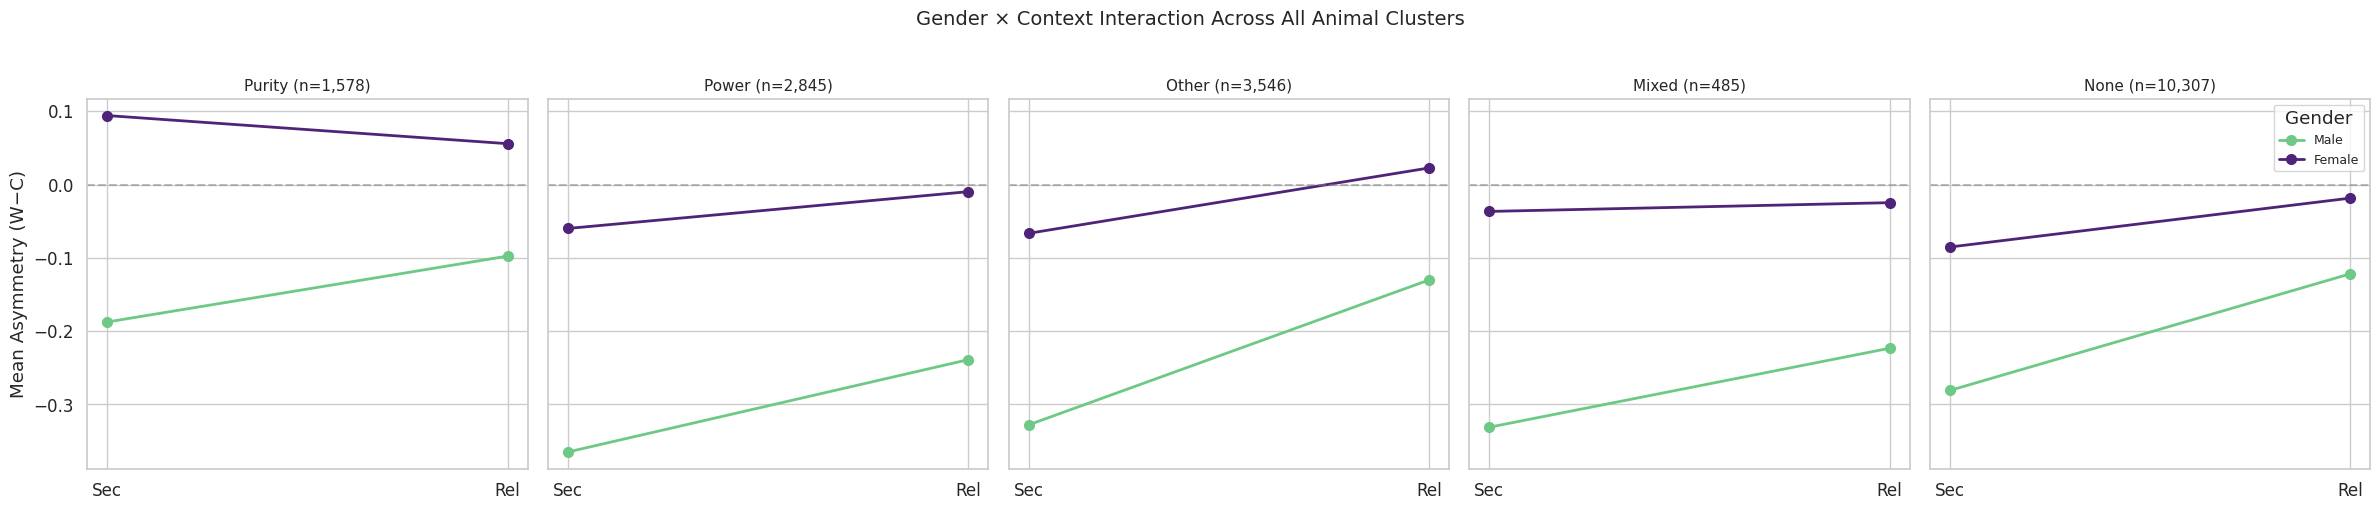

In [6]:
# ── 1d. Full 5-cluster interaction plot ──
fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)

for i, cluster in enumerate(["purity", "power", "other", "mixed", "none"]):
    data = dfa[dfa["animal_cluster"] == cluster]
    means = data.groupby(["context", "gender"])["asymmetry"].mean().unstack()
    
    for g, color in COLORS.items():
        if g in means.columns:
            vals = [means.loc[ctx, g] if ctx in means.index else np.nan 
                    for ctx in ["secular", "religious"]]
            axes[i].plot(["Sec", "Rel"], vals, 
                        "o-", color=color, linewidth=2, markersize=7, label=g)
    
    n_cl = len(data)
    axes[i].set_title(f"{cluster.title()} (n={n_cl:,})", fontsize=11)
    if i == 0:
        axes[i].set_ylabel("Mean Asymmetry (W−C)")
    axes[i].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    if i == 4:
        axes[i].legend(title="Gender", fontsize=9)

plt.suptitle("Gender × Context Interaction Across All Animal Clusters", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "h3_interaction_all_clusters.png", dpi=DPI, bbox_inches="tight")
plt.show()

---
## 2. Simple Effects: Gender Gap Within Each Cluster × Context Cell

In [7]:
# ── 2a. Simple effects: gender difference within each cluster × context ──
print("=" * 80)
print("SIMPLE EFFECTS: Gender difference within each Cluster × Context cell")
print("=" * 80)

simple_rows = []
for cluster in ["purity", "power", "other", "mixed", "none"]:
    for ctx in ["religious", "secular"]:
        m = dfa[(dfa["animal_cluster"]==cluster) & (dfa["context"]==ctx) & (dfa["gender"]=="Male")]["asymmetry"].dropna()
        f = dfa[(dfa["animal_cluster"]==cluster) & (dfa["context"]==ctx) & (dfa["gender"]=="Female")]["asymmetry"].dropna()
        
        if len(m) < 10 or len(f) < 10:
            print(f"  {cluster:8s} × {ctx:10s}: SKIPPED (n_F={len(f)}, n_M={len(m)})")
            continue
        
        t_stat, t_p = stats.ttest_ind(f, m, equal_var=False)
        u_stat, u_p = stats.mannwhitneyu(f, m, alternative="two-sided")
        d = cohens_d(f, m)
        se = np.sqrt(f.var()/len(f) + m.var()/len(m))
        gap = f.mean() - m.mean()
        ci_lo, ci_hi = gap - 1.96*se, gap + 1.96*se
        
        sig = "***" if t_p < .001 else "**" if t_p < .01 else "*" if t_p < .05 else "ns"
        
        print(f"\n  {cluster.upper():8s} × {ctx.upper():10s}:")
        print(f"    Female: mean={f.mean():+.4f} (n={len(f):,})")
        print(f"    Male:   mean={m.mean():+.4f} (n={len(m):,})")
        print(f"    Δ (F−M) = {gap:+.4f}  [95% CI: {ci_lo:+.4f}, {ci_hi:+.4f}]")
        print(f"    Cohen's d = {d:+.4f}  |  Welch t = {t_stat:.3f}, p = {t_p:.3e} {sig}")
        
        simple_rows.append({
            "Cluster": cluster, "Context": ctx,
            "n_F": len(f), "n_M": len(m),
            "Gap": gap, "CI_lo": ci_lo, "CI_hi": ci_hi,
            "d": d, "t": t_stat, "p": t_p, "sig": sig
        })

df_simple = pd.DataFrame(simple_rows)

SIMPLE EFFECTS: Gender difference within each Cluster × Context cell

  PURITY   × RELIGIOUS :
    Female: mean=+0.0557 (n=383)
    Male:   mean=-0.0976 (n=610)
    Δ (F−M) = +0.1533  [95% CI: +0.0887, +0.2180]
    Cohen's d = +0.2942  |  Welch t = 4.649, p = 3.850e-06 ***

  PURITY   × SECULAR   :
    Female: mean=+0.0941 (n=203)
    Male:   mean=-0.1875 (n=301)
    Δ (F−M) = +0.2816  [95% CI: +0.1880, +0.3752]
    Cohen's d = +0.5524  |  Welch t = 5.896, p = 8.142e-09 ***

  POWER    × RELIGIOUS :
    Female: mean=-0.0097 (n=216)
    Male:   mean=-0.2389 (n=549)
    Δ (F−M) = +0.2291  [95% CI: +0.1494, +0.3089]
    Cohen's d = +0.4451  |  Welch t = 5.631, p = 3.354e-08 ***

  POWER    × SECULAR   :
    Female: mean=-0.0599 (n=511)
    Male:   mean=-0.3648 (n=1,455)
    Δ (F−M) = +0.3049  [95% CI: +0.2539, +0.3560]
    Cohen's d = +0.5916  |  Welch t = 11.707, p = 1.294e-29 ***

  OTHER    × RELIGIOUS :
    Female: mean=+0.0226 (n=304)
    Male:   mean=-0.1302 (n=548)
    Δ (F−M) = +0

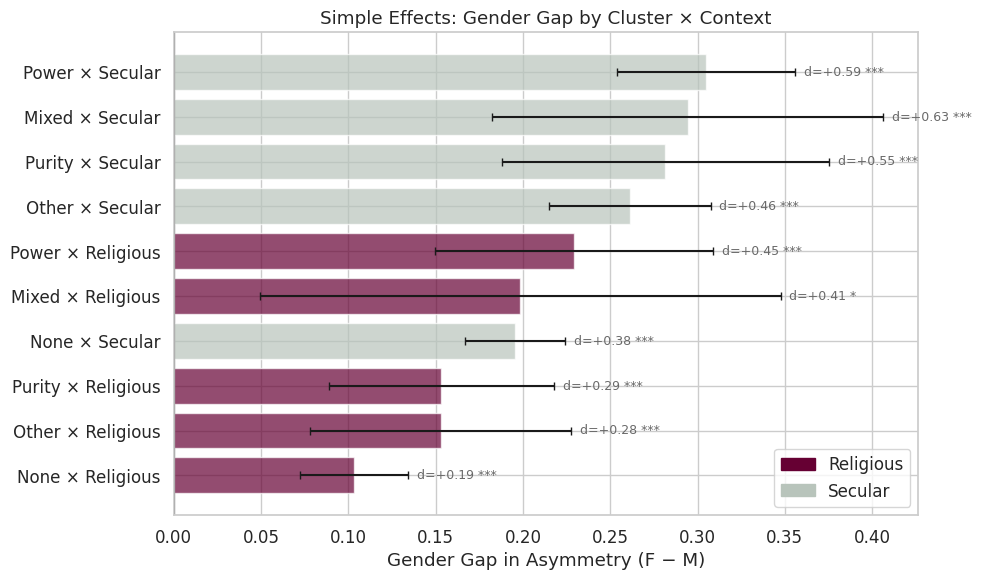

In [8]:
# ── 2b. Forest plot of gender gaps across clusters × context ──
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df_simple.copy()
plot_df["label"] = plot_df["Cluster"].str.title() + " × " + plot_df["Context"].str.title()
plot_df = plot_df.sort_values("Gap", ascending=True).reset_index(drop=True)

y_pos = range(len(plot_df))
colors_forest = [CTX_COLORS.get(row["Context"], "gray") for _, row in plot_df.iterrows()]

ax.barh(y_pos, plot_df["Gap"], xerr=[plot_df["Gap"] - plot_df["CI_lo"], plot_df["CI_hi"] - plot_df["Gap"]],
        color=colors_forest, alpha=0.7, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Gender Gap in Asymmetry (F − M)")
ax.set_title("Simple Effects: Gender Gap by Cluster × Context")

# Annotate significance
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["CI_hi"] + 0.005, i, f"d={row['d']:+.2f} {row['sig']}", 
            va="center", fontsize=9, color="dimgray")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=CTX_COLORS["religious"], label="Religious"),
                    Patch(color=CTX_COLORS["secular"], label="Secular")],
          loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "h3_forest_simple_effects.png", dpi=DPI, bbox_inches="tight")
plt.show()

---
## 3. Model 3a — H3: Fauna Presence (Layer 1)

Before testing whether the *type* of animal matters, we first test whether the mere presence of any fauna in the artwork modifies the Gender × Religious attenuation found in H2.

$$\text{Asymmetry}_i = \beta_0 + \beta_1 \cdot \text{Female} + \beta_2 \cdot \text{Religious} + \beta_3 \cdot \text{Female} \times \text{Religious}$$
$$+ \beta_4 \cdot \text{Fauna} + \beta_5 \cdot \text{Female} \times \text{Fauna} + \beta_6 \cdot \text{Religious} \times \text{Fauna}$$
$$+ \beta_7 \cdot \text{Female} \times \text{Religious} \times \text{Fauna} + \varepsilon_i$$

**Key coefficient:** β₇ — does the Gender × Religious attenuation differ in artworks that contain *any* fauna versus artworks without?

In [9]:
# ── 3a.1 Descriptive: gender gap WITH vs WITHOUT fauna ──
print("=" * 70)
print("Gender Gap in Asymmetry: Fauna Present vs Absent × Context")
print("=" * 70)

fauna_gap_rows = []
for has_fauna, label in [(1, "Fauna present"), (0, "No fauna")]:
    for ctx in ["religious", "secular"]:
        m = dfa[(dfa["is_fauna"]==has_fauna) & (dfa["context"]==ctx) & (dfa["gender"]=="Male")]["asymmetry"].dropna()
        f = dfa[(dfa["is_fauna"]==has_fauna) & (dfa["context"]==ctx) & (dfa["gender"]=="Female")]["asymmetry"].dropna()
        gap = f.mean() - m.mean()
        d = cohens_d(f, m)
        t_stat, t_p = stats.ttest_ind(f, m, equal_var=False)
        sig = "***" if t_p < .001 else "**" if t_p < .01 else "*" if t_p < .05 else "ns"
        
        print(f"\n  {label:15s} × {ctx.upper():10s}:")
        print(f"    Female: mean={f.mean():+.4f} (n={len(f):,})")
        print(f"    Male:   mean={m.mean():+.4f} (n={len(m):,})")
        print(f"    Δ (F−M) = {gap:+.4f}  d={d:+.3f}  p={t_p:.3e} {sig}")
        
        fauna_gap_rows.append({
            "Fauna": label, "Context": ctx,
            "n_F": len(f), "n_M": len(m),
            "Gap (F−M)": round(gap, 4), "d": round(d, 4)
        })

df_fauna_gaps = pd.DataFrame(fauna_gap_rows)

# Attenuation comparison
print("\n── Attenuation (Religious − Secular gap) ──")
for label in ["Fauna present", "No fauna"]:
    rel = df_fauna_gaps[(df_fauna_gaps["Fauna"]==label) & (df_fauna_gaps["Context"]=="religious")]["Gap (F−M)"].values[0]
    sec = df_fauna_gaps[(df_fauna_gaps["Fauna"]==label) & (df_fauna_gaps["Context"]=="secular")]["Gap (F−M)"].values[0]
    print(f"  {label:15s}: Religious gap={rel:+.4f}  Secular gap={sec:+.4f}  Attenuation={rel-sec:+.4f}")

Gender Gap in Asymmetry: Fauna Present vs Absent × Context

  Fauna present   × RELIGIOUS :
    Female: mean=+0.0257 (n=960)
    Male:   mean=-0.1576 (n=1,815)
    Δ (F−M) = +0.1834  d=+0.346  p=5.851e-19 ***

  Fauna present   × SECULAR   :
    Female: mean=-0.0441 (n=1,737)
    Male:   mean=-0.3313 (n=3,488)
    Δ (F−M) = +0.2872  d=+0.529  p=3.057e-70 ***

  No fauna        × RELIGIOUS :
    Female: mean=-0.0185 (n=1,630)
    Male:   mean=-0.1218 (n=2,990)
    Δ (F−M) = +0.1032  d=+0.194  p=6.113e-11 ***

  No fauna        × SECULAR   :
    Female: mean=-0.0852 (n=2,113)
    Male:   mean=-0.2808 (n=3,040)
    Δ (F−M) = +0.1956  d=+0.378  p=3.917e-40 ***

── Attenuation (Religious − Secular gap) ──
  Fauna present  : Religious gap=+0.1834  Secular gap=+0.2872  Attenuation=-0.1038
  No fauna       : Religious gap=+0.1032  Secular gap=+0.1956  Attenuation=-0.0924


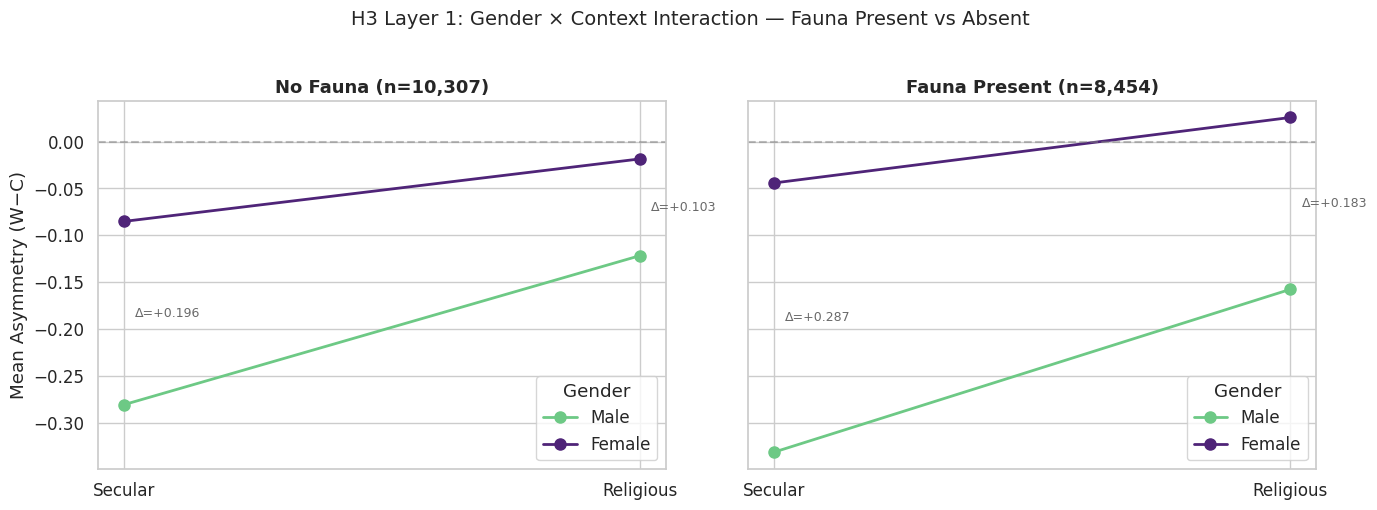

In [10]:
# ── 3a.2 Interaction plot: Fauna present vs absent ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, (fauna_val, title) in enumerate([(0, "No Fauna"), (1, "Fauna Present")]):
    data = dfa[dfa["is_fauna"] == fauna_val]
    means = data.groupby(["context", "gender"])["asymmetry"].mean().unstack()
    
    for g, color in COLORS.items():
        if g in means.columns:
            vals = [means.loc[ctx, g] if ctx in means.index else np.nan
                    for ctx in ["secular", "religious"]]
            axes[i].plot(["Secular", "Religious"], vals,
                        "o-", color=color, linewidth=2, markersize=8, label=g)
    
    n_group = len(data)
    axes[i].set_title(f"{title} (n={n_group:,})", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Mean Asymmetry (W−C)" if i == 0 else "")
    axes[i].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[i].legend(title="Gender")
    
    for j, ctx in enumerate(["secular", "religious"]):
        if "Male" in means.columns and "Female" in means.columns and ctx in means.index:
            gap = means.loc[ctx, "Female"] - means.loc[ctx, "Male"]
            mid = (means.loc[ctx, "Female"] + means.loc[ctx, "Male"]) / 2
            axes[i].annotate(f"Δ={gap:+.3f}", xy=(j, mid), fontsize=9,
                           ha="left", va="center", xytext=(8, 0),
                           textcoords="offset points", color="dimgray")

plt.suptitle("H3 Layer 1: Gender × Context Interaction — Fauna Present vs Absent", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "h3_interaction_fauna_presence.png", dpi=DPI, bbox_inches="tight")
plt.show()

In [11]:
# ── 3a.3 Model 3a: three-way interaction with fauna PRESENCE ──
dfa["is_fauna"] = dfa["is_fauna"].astype(int)

model3a = smf.ols("asymmetry ~ female * religious * is_fauna", data=dfa).fit(cov_type="HC3")

print("=" * 70)
print("Model 3a: Asymmetry ~ Female × Religious × Fauna (HC3 robust SEs)")
print("=" * 70)
print(model3a.summary())

Model 3a: Asymmetry ~ Female × Religious × Fauna (HC3 robust SEs)
                            OLS Regression Results                            
Dep. Variable:              asymmetry   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     131.8
Date:                Sat, 28 Mar 2026   Prob (F-statistic):          5.84e-190
Time:                        15:30:32   Log-Likelihood:                -13947.
No. Observations:               17773   AIC:                         2.791e+04
Df Residuals:                   17765   BIC:                         2.797e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

In [12]:
# ── 3a.4 Key coefficients ──
params_3a = model3a.params
pvals_3a  = model3a.pvalues
ci_3a     = model3a.conf_int()

coef_names_3a = {
    "Intercept":              "β₀ (Male, Secular, No Fauna)",
    "female":                  "β₁ (Female, secular no-fauna)",
    "religious":                "β₂ (Religious, males no-fauna)",
    "female:religious":         "β₃ (F×R, no fauna)",
    "is_fauna":                 "β₄ (Fauna present, males secular)",
    "female:is_fauna":          "β₅ (F×Fauna, secular)",
    "religious:is_fauna":       "β₆ (R×Fauna, males)",
    "female:religious:is_fauna":"β₇ (F×R×Fauna) ← KEY",
}

print("─" * 70)
print("MODEL 3a COEFFICIENT SUMMARY")
print("─" * 70)
for key, label in coef_names_3a.items():
    if key in params_3a.index:
        b = params_3a[key]
        p = pvals_3a[key]
        ci_lo, ci_hi = ci_3a.loc[key]
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        print(f"  {label:45s}: {b:+.4f}  [{ci_lo:+.4f}, {ci_hi:+.4f}]  p={p:.3e} {sig}")

print(f"\nR²: {model3a.rsquared:.4f}  |  N: {int(model3a.nobs):,}")

# Gender gaps from predictions
print("\n── Gender gaps (F−M) from Model 3a ──")
for fauna_label, fauna_val in [("No Fauna", 0), ("Fauna", 1)]:
    for ctx_label, ctx_val in [("Secular", 0), ("Religious", 1)]:
        pred_f = model3a.predict(pd.DataFrame({"female": [1], "religious": [ctx_val], "is_fauna": [fauna_val]}))[0]
        pred_m = model3a.predict(pd.DataFrame({"female": [0], "religious": [ctx_val], "is_fauna": [fauna_val]}))[0]
        print(f"  {fauna_label:10s} × {ctx_label:10s}: gap = {pred_f - pred_m:+.4f}")

──────────────────────────────────────────────────────────────────────
MODEL 3a COEFFICIENT SUMMARY
──────────────────────────────────────────────────────────────────────
  β₀ (Male, Secular, No Fauna)                 : -0.2808  [-0.2994, -0.2623]  p=1.638e-193 ***
  β₁ (Female, secular no-fauna)                : +0.1956  [+0.1670, +0.2242]  p=7.264e-41 ***
  β₂ (Religious, males no-fauna)               : +0.1591  [+0.1319, +0.1863]  p=1.969e-30 ***
  β₃ (F×R, no fauna)                           : -0.0924  [-0.1344, -0.0503]  p=1.710e-05 ***
  β₄ (Fauna present, males secular)            : -0.0505  [-0.0764, -0.0246]  p=1.340e-04 ***
  β₅ (F×Fauna, secular)                        : +0.0916  [+0.0494, +0.1339]  p=2.147e-05 ***
  β₆ (R×Fauna, males)                          : +0.0146  [-0.0267, +0.0559]  p=4.878e-01 ns
  β₇ (F×R×Fauna) ← KEY                         : -0.0115  [-0.0774, +0.0544]  p=7.329e-01 ns

R²: 0.0479  |  N: 17,773

── Gender gaps (F−M) from Model 3a ──
  No Fauna   

In [13]:
# ── 3a.5 Model 3a across all three outcomes ──
print("=" * 70)
print("Model 3a across outcomes (β₇ = F×R×Fauna)")
print("=" * 70)

b7_fauna_key = "female:religious:is_fauna"

OUTCOMES = [
    ("asymmetry",          "Asymmetry (W−C)"),
    ("dirmean_Warmth",     "Warmth"),
    ("dirmean_Competence", "Competence"),
]

m3a_rows = []
for col, label in OUTCOMES:
    m = smf.ols(f"{col} ~ female * religious * is_fauna", data=dfa).fit(cov_type="HC3")
    b7 = m.params.get(b7_fauna_key, np.nan)
    p7 = m.pvalues.get(b7_fauna_key, np.nan)
    ci = m.conf_int().loc[b7_fauna_key]
    b3 = m.params.get("female:religious", np.nan)
    sig = "***" if p7 < .001 else "**" if p7 < .01 else "*" if p7 < .05 else "ns"
    
    print(f"\n  {label}:")
    print(f"    β₃ (F×R, no fauna) = {b3:+.4f}")
    print(f"    β₇ (F×R×Fauna)     = {b7:+.4f}  [CI: {ci[0]:+.4f}, {ci[1]:+.4f}]  p={p7:.3e} {sig}")
    
    m3a_rows.append({"Outcome": label, "β₃ (F×R)": round(b3, 4),
                     "β₇ (F×R×Fauna)": round(b7, 4),
                     "CI_lo": round(ci[0], 4), "CI_hi": round(ci[1], 4),
                     "p-value": p7, "sig": sig, "R²": round(m.rsquared, 4)})

df_m3a_outcomes = pd.DataFrame(m3a_rows)
print("\n")
display(df_m3a_outcomes)

Model 3a across outcomes (β₇ = F×R×Fauna)

  Asymmetry (W−C):
    β₃ (F×R, no fauna) = -0.0924
    β₇ (F×R×Fauna)     = -0.0115  [CI: -0.0774, +0.0544]  p=7.329e-01 ns

  Warmth:
    β₃ (F×R, no fauna) = +0.0591
    β₇ (F×R×Fauna)     = -0.0903  [CI: -0.1376, -0.0431]  p=1.763e-04 ***

  Competence:
    β₃ (F×R, no fauna) = +0.1583
    β₇ (F×R×Fauna)     = -0.0830  [CI: -0.1358, -0.0302]  p=2.067e-03 **




,Outcome,β₃ (F×R),β₇ (F×R×Fauna),CI_lo,CI_hi,p-value,sig,R²
0,Asymmetry (W−C),-0.0924,-0.0115,-0.0774,0.0544,0.732923,ns,0.0479
1,Warmth,0.0591,-0.0903,-0.1376,-0.0431,0.000176,***,0.0370
2,Competence,0.1583,-0.0830,-0.1358,-0.0302,0.002067,**,0.0173


In [14]:
# ── 3a.6 Robustness for Model 3a ──
print("\nModel 3a ROBUSTNESS (β₇ = F×R×Fauna)")
print("=" * 70)

# Clustered
dfa_clean = dfa.dropna(subset=["asymmetry"]).copy()
m3a_cl = smf.ols("asymmetry ~ female * religious * is_fauna", data=dfa_clean).fit(
    cov_type="cluster", cov_kwds={"groups": dfa_clean["cat_no"]})

# Century FE
dfa_cent = dfa[dfa["century_num"].notna()].copy()
m3a_century = smf.ols("asymmetry ~ female * religious * is_fauna + C(century_bin)",
                       data=dfa_cent).fit(cov_type="HC3")

# Both
dfa_cent_clean = dfa_cent.dropna(subset=["asymmetry"]).copy()
m3a_full = smf.ols("asymmetry ~ female * religious * is_fauna + C(century_bin)",
                    data=dfa_cent_clean).fit(
    cov_type="cluster", cov_kwds={"groups": dfa_cent_clean["cat_no"]})

specs_3a = [
    ("OLS + HC3 (primary)",          model3a),
    ("OLS + Clustered SE",           m3a_cl),
    ("OLS + HC3 + Century FE",       m3a_century),
    ("OLS + Clustered + Century FE", m3a_full),
]

rob_3a_rows = []
for label, m in specs_3a:
    b7 = m.params[b7_fauna_key]
    ci = m.conf_int().loc[b7_fauna_key]
    p  = m.pvalues[b7_fauna_key]
    rob_3a_rows.append({
        "Specification": label,
        "β₇ (F×R×Fauna)": f"{b7:+.4f}",
        "95% CI": f"[{ci[0]:+.4f}, {ci[1]:+.4f}]",
        "p-value": f"{p:.2e}",
        "R²": f"{m.rsquared:.4f}",
    })

display(pd.DataFrame(rob_3a_rows))


Model 3a ROBUSTNESS (β₇ = F×R×Fauna)


,Specification,β₇ (F×R×Fauna),95% CI,p-value,R²
0,OLS + HC3 (primary),-0.0115,"[-0.0774, +0.0544]",7.33e-01,0.0479
1,OLS + Clustered SE,-0.0115,"[-0.0831, +0.0602]",7.54e-01,0.0479
2,OLS + HC3 + Century FE,-0.0113,"[-0.0772, +0.0546]",7.38e-01,0.0497
3,OLS + Clustered + Century FE,-0.0113,"[-0.0829, +0.0604]",7.58e-01,0.0497


---
## 4. Model 3b — H3: Iconographic Cluster Type (Layer 2)

Having established that fauna presence itself does not moderate the Gender × Religious attenuation, we now test whether the specific *type* of animal — classified by Christian iconographic function — further differentiates the effect. This is a more granular test that is conditional on Layer 1.


$$\text{Asymmetry}_i = \beta_0 + \beta_1 \cdot \text{Female} + \beta_2 \cdot \text{Religious} + \beta_3 \cdot \text{Female} \times \text{Religious}$$
$$+ \beta_4 \cdot \text{Purity} + \beta_5 \cdot \text{Female} \times \text{Purity} + \beta_6 \cdot \text{Religious} \times \text{Purity}$$
$$+ \beta_7 \cdot \text{Female} \times \text{Religious} \times \text{Purity} + \varepsilon_i$$

**Key coefficient:** β₇ — does the Gender × Religious attenuation differ when purity animals are present?

In [15]:
# ── 3a. Fit Model 3: three-way interaction with Purity ──
model3 = smf.ols("asymmetry ~ female * religious * is_purity", data=dfa).fit(cov_type="HC3")

print("=" * 70)
print("Model 3: Asymmetry ~ Female × Religious × Purity (HC3 robust SEs)")
print("=" * 70)
print(model3.summary())

Model 3: Asymmetry ~ Female × Religious × Purity (HC3 robust SEs)
                            OLS Regression Results                            
Dep. Variable:              asymmetry   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     134.3
Date:                Sat, 28 Mar 2026   Prob (F-statistic):          1.56e-193
Time:                        15:30:44   Log-Likelihood:                -13939.
No. Observations:               17773   AIC:                         2.789e+04
Df Residuals:                   17765   BIC:                         2.796e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [16]:
# ── 3b. Key coefficients summary ──
params3 = model3.params
ci3     = model3.conf_int()
pvals3  = model3.pvalues

coef_names = {
    "Intercept":                        "β₀ (Male, Secular, No Purity)",
    "female":                            "β₁ (Female, in secular no-purity)",
    "religious":                          "β₂ (Religious, for males no-purity)",
    "female:religious":                   "β₃ (F×R, no purity)",
    "is_purity":                          "β₄ (Purity, for males secular)",
    "female:is_purity":                   "β₅ (F×Purity, secular)",
    "religious:is_purity":                "β₆ (R×Purity, males)",
    "female:religious:is_purity":         "β₇ (F×R×Purity) ← KEY",
}

print("─" * 70)
print("MODEL 3 COEFFICIENT SUMMARY")
print("─" * 70)
for key, label in coef_names.items():
    if key in params3.index:
        b = params3[key]
        p = pvals3[key]
        ci_lo, ci_hi = ci3.loc[key]
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        print(f"  {label:45s}: {b:+.4f}  [{ci_lo:+.4f}, {ci_hi:+.4f}]  p={p:.3e} {sig}")

print(f"\nR²: {model3.rsquared:.4f}  |  N: {int(model3.nobs):,}")

──────────────────────────────────────────────────────────────────────
MODEL 3 COEFFICIENT SUMMARY
──────────────────────────────────────────────────────────────────────
  β₀ (Male, Secular, No Purity)                : -0.3136  [-0.3270, -0.3003]  p=0.000e+00 ***
  β₁ (Female, in secular no-purity)            : +0.2380  [+0.2165, +0.2595]  p=3.366e-104 ***
  β₂ (Religious, for males no-purity)          : +0.1728  [+0.1514, +0.1942]  p=2.338e-56 ***
  β₃ (F×R, no purity)                          : -0.1093  [-0.1434, -0.0753]  p=3.138e-10 ***
  β₄ (Purity, for males secular)               : +0.1261  [+0.0708, +0.1815]  p=7.960e-06 ***
  β₅ (F×Purity, secular)                       : +0.0436  [-0.0527, +0.1398]  p=3.748e-01 ns
  β₆ (R×Purity, males)                         : -0.0829  [-0.1552, -0.0107]  p=2.448e-02 *
  β₇ (F×R×Purity) ← KEY                        : -0.0189  [-0.1378, +0.1000]  p=7.555e-01 ns

R²: 0.0487  |  N: 17,773


In [17]:
# ── 3c. Marginal predictions for all 8 cells ──
print("─" * 70)
print("MARGINAL PREDICTIONS (Model 3)")
print("─" * 70)

pred_rows = []
for fem in [0, 1]:
    for rel in [0, 1]:
        for pur in [0, 1]:
            pred_df = pd.DataFrame({"female": [fem], "religious": [rel], "is_purity": [pur]})
            pred_val = model3.predict(pred_df)[0]
            g = "Female" if fem else "Male"
            c = "Religious" if rel else "Secular"
            p = "Purity" if pur else "No Purity"
            pred_rows.append({"Gender": g, "Context": c, "Purity": p, "Predicted Asym": round(pred_val, 4)})
            print(f"  {g:7s}, {c:10s}, {p:10s}: {pred_val:+.4f}")

df_pred3 = pd.DataFrame(pred_rows)

# Gender gaps
print("\n── Gender gaps (F−M) ──")
for pur_label in ["No Purity", "Purity"]:
    for ctx_label in ["Secular", "Religious"]:
        f_pred = df_pred3[(df_pred3["Gender"]=="Female") & (df_pred3["Context"]==ctx_label) & (df_pred3["Purity"]==pur_label)]["Predicted Asym"].values[0]
        m_pred = df_pred3[(df_pred3["Gender"]=="Male") & (df_pred3["Context"]==ctx_label) & (df_pred3["Purity"]==pur_label)]["Predicted Asym"].values[0]
        print(f"  {pur_label:10s} × {ctx_label:10s}: gap = {f_pred - m_pred:+.4f}")

──────────────────────────────────────────────────────────────────────
MARGINAL PREDICTIONS (Model 3)
──────────────────────────────────────────────────────────────────────
  Male   , Secular   , No Purity : -0.3136
  Male   , Secular   , Purity    : -0.1875
  Male   , Religious , No Purity : -0.1408
  Male   , Religious , Purity    : -0.0976
  Female , Secular   , No Purity : -0.0756
  Female , Secular   , Purity    : +0.0941
  Female , Religious , No Purity : -0.0122
  Female , Religious , Purity    : +0.0557

── Gender gaps (F−M) ──
  No Purity  × Secular   : gap = +0.2380
  No Purity  × Religious : gap = +0.1286
  Purity     × Secular   : gap = +0.2816
  Purity     × Religious : gap = +0.1533


---
## 5. Model 4 — H3(b): Cluster Type as Categorical Moderator

Uses `animal_cluster` as a categorical variable (reference = none) to test whether the degree of gender equalization varies systematically across symbolic clusters.

In [18]:
# ── 4a. Fit Model 4: three-way interaction with cluster type ──
# Reference category = 'none' (artworks without fauna)
model4 = smf.ols(
    "asymmetry ~ female * religious * C(animal_cluster, Treatment(reference='none'))",
    data=dfa
).fit(cov_type="HC3")

print("=" * 70)
print("Model 4: Asymmetry ~ Female × Religious × C(animal_cluster) [HC3]")
print("=" * 70)
print(model4.summary())

Model 4: Asymmetry ~ Female × Religious × C(animal_cluster) [HC3]
                            OLS Regression Results                            
Dep. Variable:              asymmetry   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     52.60
Date:                Sat, 28 Mar 2026   Prob (F-statistic):          3.46e-194
Time:                        15:30:54   Log-Likelihood:                -13911.
No. Observations:               17773   AIC:                         2.786e+04
Df Residuals:                   17753   BIC:                         2.802e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                                                                coef    std err          z      P>|z|      [0.025      0.975]
--

In [19]:
# Get all coefficients as a dataframe - shows every row
params = pd.DataFrame({
    'coef': model4.params,
    'std_err': model4.bse,
    'z': model4.tvalues,
    'p': model4.pvalues,
    'CI_low': model4.conf_int()[0],
    'CI_high': model4.conf_int()[1]
})

# Filter to just the three-way interaction rows
threeway = params[params.index.str.contains('female:religious') | 
                  params.index.str.contains('religious:female')]
print(threeway.round(4))

                                                      coef  std_err       z  \
female:religious                                   -0.0924   0.0215 -4.2998   
female:religious:C(animal_cluster, Treatment(re... -0.0035   0.0980 -0.0354   
female:religious:C(animal_cluster, Treatment(re... -0.0161   0.0498 -0.3234   
female:religious:C(animal_cluster, Treatment(re...  0.0166   0.0529  0.3133   
female:religious:C(animal_cluster, Treatment(re... -0.0359   0.0620 -0.5790   

                                                         p  CI_low  CI_high  
female:religious                                    0.0000 -0.1344  -0.0503  
female:religious:C(animal_cluster, Treatment(re...  0.9718 -0.1956   0.1887  
female:religious:C(animal_cluster, Treatment(re...  0.7464 -0.1136   0.0814  
female:religious:C(animal_cluster, Treatment(re...  0.7540 -0.0872   0.1204  
female:religious:C(animal_cluster, Treatment(re...  0.5626 -0.1574   0.0856  


In [20]:
# ── 4b. Extract the three-way interaction terms ──
print("─" * 70)
print("MODEL 4: Three-way interaction coefficients (F×R×Cluster)")
print("─" * 70)

threeway_rows = []
for key in model4.params.index:
    if "female:religious" in key and "animal_cluster" in key:
        # Extract cluster name
        cluster_name = key.split("'")[-2] if "'" in key else key.split("[")[1].split("]")[0] if "[" in key else key
        b = model4.params[key]
        p = model4.pvalues[key]
        ci_lo, ci_hi = model4.conf_int().loc[key]
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        print(f"  {key:65s}: β = {b:+.4f}  [{ci_lo:+.4f}, {ci_hi:+.4f}]  p={p:.3e} {sig}")
        threeway_rows.append({"term": key, "cluster": cluster_name, "beta": b, 
                              "ci_lo": ci_lo, "ci_hi": ci_hi, "p": p, "sig": sig})

df_threeway = pd.DataFrame(threeway_rows)
print(f"\nR²: {model4.rsquared:.4f}  |  N: {int(model4.nobs):,}")

──────────────────────────────────────────────────────────────────────
MODEL 4: Three-way interaction coefficients (F×R×Cluster)
──────────────────────────────────────────────────────────────────────
  female:religious:C(animal_cluster, Treatment(reference='none'))[T.mixed]: β = -0.0035  [-0.1956, +0.1887]  p=9.718e-01 ns
  female:religious:C(animal_cluster, Treatment(reference='none'))[T.other]: β = -0.0161  [-0.1136, +0.0814]  p=7.464e-01 ns
  female:religious:C(animal_cluster, Treatment(reference='none'))[T.power]: β = +0.0166  [-0.0872, +0.1204]  p=7.540e-01 ns
  female:religious:C(animal_cluster, Treatment(reference='none'))[T.purity]: β = -0.0359  [-0.1574, +0.0856]  p=5.626e-01 ns

R²: 0.0517  |  N: 17,773


In [22]:
# ── 4c. Purity vs Power direct contrast ──
# Re-run with power as reference to get direct purity-vs-power comparison
model4_power_ref = smf.ols(
    "asymmetry ~ female * religious * C(animal_cluster, Treatment(reference='power'))",
    data=dfa
).fit(cov_type="HC3")

print("─" * 70)
print("MODEL 4 (power as reference): Purity vs Power contrast")
print("─" * 70)

for key in model4_power_ref.params.index:
    if "female:religious" in key and "purity" in key.lower():
        b = model4_power_ref.params[key]
        p = model4_power_ref.pvalues[key]
        ci_lo, ci_hi = model4_power_ref.conf_int().loc[key]
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        print(f"  Purity vs Power (F×R×Purity): β = {b:+.4f}  [{ci_lo:+.4f}, {ci_hi:+.4f}]  p={p:.3e} {sig}")

──────────────────────────────────────────────────────────────────────
MODEL 4 (power as reference): Purity vs Power contrast
──────────────────────────────────────────────────────────────────────
  Purity vs Power (F×R×Purity): β = -0.0525  [-0.2008, +0.0958]  p=4.879e-01 ns


---
## 6. Robustness: Warmth and Competence as Separate DVs

In [23]:
# ── 5a. Model 3 across outcomes ──
OUTCOMES = [
    ("asymmetry",          "Asymmetry (W−C)"),
    ("dirmean_Warmth",     "Warmth"),
    ("dirmean_Competence", "Competence"),
]

print("=" * 70)
print("ROBUSTNESS: Model 3 across outcomes (β₇ = F×R×Purity)")
print("=" * 70)

rob_rows = []
for col, label in OUTCOMES:
    m = smf.ols(f"{col} ~ female * religious * is_purity", data=dfa).fit(cov_type="HC3")
    
    b7_key = "female:religious:is_purity"
    b7 = m.params.get(b7_key, np.nan)
    p7 = m.pvalues.get(b7_key, np.nan)
    ci = m.conf_int().loc[b7_key] if b7_key in m.params.index else [np.nan, np.nan]
    sig = "***" if p7 < .001 else "**" if p7 < .01 else "*" if p7 < .05 else "ns"
    
    # Also get β₃ (F×R without purity) for comparison
    b3 = m.params.get("female:religious", np.nan)
    
    print(f"\n  {label}:")
    print(f"    β₃ (F×R, no purity)    = {b3:+.4f}")
    print(f"    β₇ (F×R×Purity)        = {b7:+.4f}  [CI: {ci[0]:+.4f}, {ci[1]:+.4f}]  p={p7:.3e} {sig}")
    
    rob_rows.append({"Outcome": label, "β₃ (F×R)": round(b3, 4),
                     "β₇ (F×R×Purity)": round(b7, 4), 
                     "CI_lo": round(ci[0], 4), "CI_hi": round(ci[1], 4),
                     "p-value": p7, "sig": sig, "R²": round(m.rsquared, 4)})

df_rob_outcomes = pd.DataFrame(rob_rows)
print("\n")
display(df_rob_outcomes)

ROBUSTNESS: Model 3 across outcomes (β₇ = F×R×Purity)

  Asymmetry (W−C):
    β₃ (F×R, no purity)    = -0.1093
    β₇ (F×R×Purity)        = -0.0189  [CI: -0.1378, +0.1000]  p=7.555e-01 ns

  Warmth:
    β₃ (F×R, no purity)    = +0.0122
    β₇ (F×R×Purity)        = -0.0488  [CI: -0.1340, +0.0365]  p=2.621e-01 ns

  Competence:
    β₃ (F×R, no purity)    = +0.1285
    β₇ (F×R×Purity)        = -0.0471  [CI: -0.1449, +0.0506]  p=3.448e-01 ns




,Outcome,β₃ (F×R),β₇ (F×R×Purity),CI_lo,CI_hi,p-value,sig,R²
0,Asymmetry (W−C),-0.1093,-0.0189,-0.1378,0.1000,0.755480,ns,0.0487
1,Warmth,0.0122,-0.0488,-0.1340,0.0365,0.262137,ns,0.0337
2,Competence,0.1285,-0.0471,-0.1449,0.0506,0.344762,ns,0.0169


---
## 6. Sensitivity Checks

In [24]:
# ── 6a. Coverage filter: exclude figures with <30% SADCAT coverage ──
dfa_filtered = dfa[dfa["coverage_pct"] >= 30].copy()
print(f"Coverage ≥30%: {len(dfa_filtered):,} figures ({len(dfa_filtered)/len(dfa)*100:.1f}% of original)")

m3_filtered = smf.ols("asymmetry ~ female * religious * is_purity",
                       data=dfa_filtered).fit(cov_type="HC3")

b7_key = "female:religious:is_purity"
b7_f = m3_filtered.params[b7_key]
p7_f = m3_filtered.pvalues[b7_key]
ci7_f = m3_filtered.conf_int().loc[b7_key]

print(f"\nModel 3 (coverage ≥30%):")
print(f"  β₇ = {b7_f:+.4f}  [CI: {ci7_f[0]:+.4f}, {ci7_f[1]:+.4f}]")
print(f"  p   = {p7_f:.3e}")
print(f"\nOriginal β₇: {model3.params[b7_key]:+.4f}")
print(f"→ Change: {b7_f - model3.params[b7_key]:+.4f}")

Coverage ≥30%: 18,646 figures (99.4% of original)

Model 3 (coverage ≥30%):
  β₇ = -0.0083  [CI: -0.1264, +0.1097]
  p   = 8.899e-01

Original β₇: -0.0189
→ Change: +0.0106


In [25]:
# ── 6b. Century fixed effects ──
dfa_cent = dfa[dfa["century_num"].notna()].copy()

m3_century = smf.ols("asymmetry ~ female * religious * is_purity + C(century_bin)",
                      data=dfa_cent).fit(cov_type="HC3")

b7_c = m3_century.params[b7_key]
p7_c = m3_century.pvalues[b7_key]
ci7_c = m3_century.conf_int().loc[b7_key]

print(f"Figures with century: {len(dfa_cent):,}")
print(f"\nModel 3 + Century FE:")
print(f"  β₇ = {b7_c:+.4f}  [CI: {ci7_c[0]:+.4f}, {ci7_c[1]:+.4f}]")
print(f"  p   = {p7_c:.3e}")
print(f"\n→ Change vs baseline: {b7_c - model3.params[b7_key]:+.4f}")

Figures with century: 18,761

Model 3 + Century FE:
  β₇ = -0.0207  [CI: -0.1392, +0.0978]
  p   = 7.322e-01

→ Change vs baseline: -0.0018


In [26]:
# ── 6c. Clustered standard errors by artwork ──
dfa_clean = dfa.dropna(subset=["asymmetry"]).copy()

m3_clustered = smf.ols("asymmetry ~ female * religious * is_purity", data=dfa_clean).fit(
    cov_type="cluster",
    cov_kwds={"groups": dfa_clean["cat_no"]}
)

b7_cl = m3_clustered.params[b7_key]
p7_cl = m3_clustered.pvalues[b7_key]
ci7_cl = m3_clustered.conf_int().loc[b7_key]

print("Model 3 — Clustered SEs (by artwork):")
print(f"  β₇ = {b7_cl:+.4f}")
print(f"  95% CI: [{ci7_cl[0]:+.4f}, {ci7_cl[1]:+.4f}]")
print(f"  p = {p7_cl:.2e}")

Model 3 — Clustered SEs (by artwork):
  β₇ = -0.0189
  95% CI: [-0.1493, +0.1115]
  p = 7.76e-01


In [27]:
# ── 6d. Most conservative: clustered + century FE ──
dfa_cent_clean = dfa_cent.dropna(subset=["asymmetry"]).copy()

m3_full = smf.ols("asymmetry ~ female * religious * is_purity + C(century_bin)",
                   data=dfa_cent_clean).fit(
    cov_type="cluster",
    cov_kwds={"groups": dfa_cent_clean["cat_no"]}
)

b7_full = m3_full.params[b7_key]
p7_full = m3_full.pvalues[b7_key]
ci7_full = m3_full.conf_int().loc[b7_key]

print("Most conservative — Model 3 + Century FE + Clustered:")
print(f"  β₇ = {b7_full:+.4f}")
print(f"  95% CI: [{ci7_full[0]:+.4f}, {ci7_full[1]:+.4f}]")
print(f"  p = {p7_full:.2e}")

Most conservative — Model 3 + Century FE + Clustered:
  β₇ = -0.0207
  95% CI: [-0.1509, +0.1095]
  p = 7.55e-01


In [28]:
# ── 6e. Robustness summary table ──
print("\nH3 ROBUSTNESS SUMMARY (Model 3 — β₇ = F×R×Purity)")
print("=" * 70)

specs = [
    ("OLS + HC3 (primary)",             model3),
    ("OLS + Clustered SE",              m3_clustered),
    ("OLS + HC3 + Century FE",          m3_century),
    ("OLS + Clustered + Century FE",    m3_full),
]

rob_summary_rows = []
for label, m in specs:
    b7 = m.params[b7_key]
    ci = m.conf_int().loc[b7_key]
    p  = m.pvalues[b7_key]
    rob_summary_rows.append({
        "Specification": label,
        "β₇ (F×R×Pur)": f"{b7:+.4f}",
        "95% CI": f"[{ci[0]:+.4f}, {ci[1]:+.4f}]",
        "p-value": f"{p:.2e}",
        "R²": f"{m.rsquared:.4f}",
    })

df_rob_summary = pd.DataFrame(rob_summary_rows)
display(df_rob_summary)


H3 ROBUSTNESS SUMMARY (Model 3 — β₇ = F×R×Purity)


,Specification,β₇ (F×R×Pur),95% CI,p-value,R²
0,OLS + HC3 (primary),-0.0189,"[-0.1378, +0.1000]",7.55e-01,0.0487
1,OLS + Clustered SE,-0.0189,"[-0.1493, +0.1115]",7.76e-01,0.0487
2,OLS + HC3 + Century FE,-0.0207,"[-0.1392, +0.0978]",7.32e-01,0.0509
3,OLS + Clustered + Century FE,-0.0207,"[-0.1509, +0.1095]",7.55e-01,0.0509


---
## 7. Subfacet Breakdown: Which SADCAT Dimensions Does Purity Moderate?

In [29]:
# ── 7a. Run Model 3 for every SADCAT subfacet ──
SUBFACETS = ["Warmth", "Competence", "Sociability", "Morality", "Ability", 
             "Assertiveness", "Status", "Beliefs", "Politics", "Religion"]

subfacet_rows = []

for dim in SUBFACETS:
    col = f"dirmean_{dim}"
    if col not in dfa.columns:
        continue
    m = smf.ols(f"{col} ~ female * religious * is_purity", data=dfa).fit(cov_type="HC3")
    
    b7 = m.params.get(b7_key, np.nan)
    p7 = m.pvalues.get(b7_key, np.nan)
    ci = m.conf_int().loc[b7_key] if b7_key in m.params.index else [np.nan, np.nan]
    b3 = m.params.get("female:religious", np.nan)
    
    subfacet_rows.append({
        "Dimension": dim,
        "β₃ (F×R)": round(b3, 4),
        "β₇ (F×R×Purity)": round(b7, 4),
        "CI_lo": round(ci[0], 4), "CI_hi": round(ci[1], 4),
        "p-value": p7,
        "sig": "***" if p7 < .001 else "**" if p7 < .01 else "*" if p7 < .05 else "ns"
    })

df_subfacets = pd.DataFrame(subfacet_rows).sort_values("β₇ (F×R×Purity)", ascending=False)

print("=" * 70)
print("β₇ (F×R×Purity) across ALL SADCAT dimensions")
print("=" * 70)
display(df_subfacets)

β₇ (F×R×Purity) across ALL SADCAT dimensions


,Dimension,β₃ (F×R),β₇ (F×R×Purity),CI_lo,CI_hi,p-value,sig
4,Ability,0.0097,0.0310,-0.0118,0.0738,0.155858,ns
8,Politics,-0.0760,0.0139,-0.1918,0.2196,0.894861,ns
9,Religion,0.0181,0.0091,-0.0282,0.0464,0.632521,ns
6,Status,0.0166,-0.0280,-0.1332,0.0772,0.601795,ns
3,Morality,0.0311,-0.0393,-0.1539,0.0752,0.500663,ns
1,Competence,0.1285,-0.0471,-0.1449,0.0506,0.344762,ns
0,Warmth,0.0122,-0.0488,-0.1340,0.0365,0.262137,ns
7,Beliefs,-0.0726,-0.0600,-0.2582,0.1382,0.552973,ns
2,Sociability,0.0548,-0.0996,-0.2030,0.0038,0.058932,ns
5,Assertiveness,0.1730,-0.1533,-0.3165,0.0100,0.065727,ns


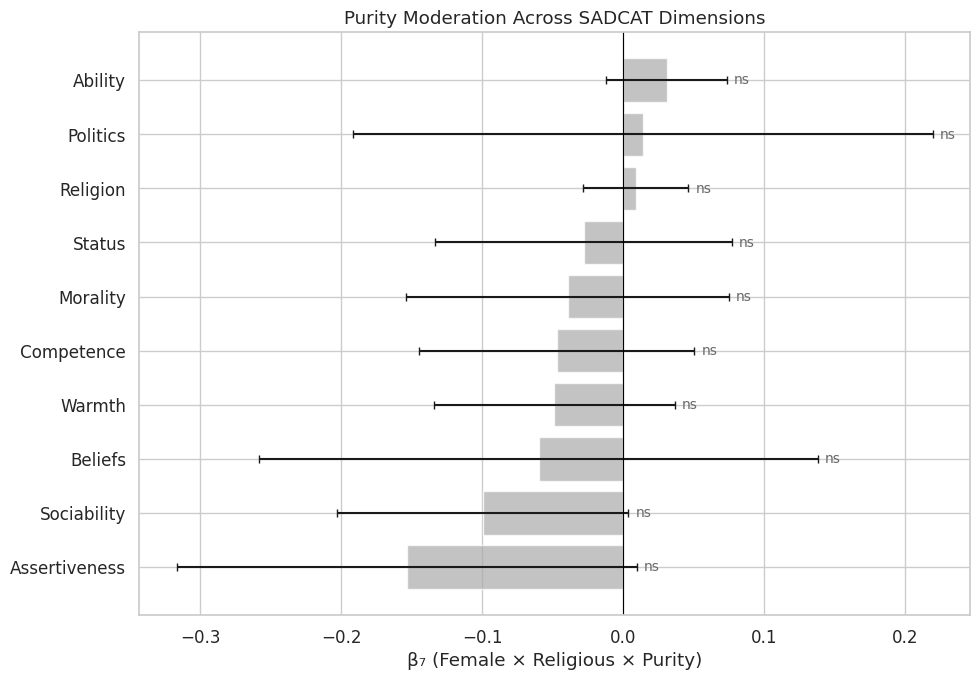

In [30]:
# ── 7b. Subfacet forest plot ──
fig, ax = plt.subplots(figsize=(10, 7))

dims_plot = df_subfacets.sort_values("β₇ (F×R×Purity)").reset_index(drop=True)
y_pos = range(len(dims_plot))

colors_sf = ["#D94A4A" if p < 0.05 else "#AAAAAA" for p in dims_plot["p-value"]]

ax.barh(y_pos, dims_plot["β₇ (F×R×Purity)"],
        xerr=[dims_plot["β₇ (F×R×Purity)"] - dims_plot["CI_lo"],
              dims_plot["CI_hi"] - dims_plot["β₇ (F×R×Purity)"]],
        color=colors_sf, alpha=0.7, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(dims_plot["Dimension"])
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("β₇ (Female × Religious × Purity)")
ax.set_title("Purity Moderation Across SADCAT Dimensions")

for i, (_, row) in enumerate(dims_plot.iterrows()):
    ax.text(row["CI_hi"] + 0.005, i, row["sig"], va="center", fontsize=10, color="dimgray")

plt.tight_layout()
plt.savefig(FIG_DIR / "h3_subfacet_purity_moderation.png", dpi=DPI, bbox_inches="tight")
plt.show()

---
## 8. H3 Results Summary

In [31]:
# ── 8. Full H3 summary ──
print("=" * 80)
print("H3 RESULTS SUMMARY")
print("Hypothesis: Animal symbolism moderates the Gender × Religious effect on W−C")
print("=" * 80)

# Model 3
b7_main = model3.params[b7_key]
p7_main = model3.pvalues[b7_key]
ci7_main = model3.conf_int().loc[b7_key]
sig_main = "***" if p7_main < .001 else "**" if p7_main < .01 else "*" if p7_main < .05 else "ns"

print(f"\nModel 3 (HC3 robust SEs): Asymmetry ~ Female × Religious × Purity")
print(f"  β₇ (F×R×Purity):  {b7_main:+.4f}  [CI: {ci7_main[0]:+.4f}, {ci7_main[1]:+.4f}]  p={p7_main:.3e} {sig_main}")
print(f"  R²: {model3.rsquared:.4f}  |  N: {int(model3.nobs):,}")

# Marginal gender gaps
print(f"\nGender gaps in asymmetry (from Model 3 predictions):")
for pur_label, pur_val in [("No Purity", 0), ("Purity", 1)]:
    for ctx_label, ctx_val in [("Secular", 0), ("Religious", 1)]:
        pred_f = model3.predict(pd.DataFrame({"female": [1], "religious": [ctx_val], "is_purity": [pur_val]}))[0]
        pred_m = model3.predict(pd.DataFrame({"female": [0], "religious": [ctx_val], "is_purity": [pur_val]}))[0]
        gap = pred_f - pred_m
        print(f"  {pur_label:10s} × {ctx_label:10s}: {gap:+.4f}")

# Robustness
print(f"\nRobustness (β₇ across specifications):")
for _, row in df_rob_summary.iterrows():
    print(f"  {row['Specification']:35s}: β₇ = {row['β₇ (F×R×Pur)']:>8s}  {row['95% CI']:>25s}  p={row['p-value']}")

# Verdict
print(f"\nVERDICT:")
if p7_main < 0.05:
    direction = "stronger" if b7_main < 0 else "weaker"
    print(f"  ~ H3(a) SUPPORTED: Purity animals are associated with {direction}")
    print(f"    attenuation of the Gender × Religious effect (β₇ = {b7_main:+.4f}, p = {p7_main:.3e}).")
else:
    print(f"  ~ H3(a) NOT SUPPORTED: No significant purity moderation (β₇ = {b7_main:+.4f}, p = {p7_main:.3e}).")
    print(f"    Animal symbolic clusters do not significantly differentiate the Gender × Religious effect.")

H3 RESULTS SUMMARY
Hypothesis: Animal symbolism moderates the Gender × Religious effect on W−C

Model 3 (HC3 robust SEs): Asymmetry ~ Female × Religious × Purity
  β₇ (F×R×Purity):  -0.0189  [CI: -0.1378, +0.1000]  p=7.555e-01 ns
  R²: 0.0487  |  N: 17,773

Gender gaps in asymmetry (from Model 3 predictions):
  No Purity  × Secular   : +0.2380
  No Purity  × Religious : +0.1286
  Purity     × Secular   : +0.2816
  Purity     × Religious : +0.1533

Robustness (β₇ across specifications):
  OLS + HC3 (primary)                : β₇ =  -0.0189         [-0.1378, +0.1000]  p=7.55e-01
  OLS + Clustered SE                 : β₇ =  -0.0189         [-0.1493, +0.1115]  p=7.76e-01
  OLS + HC3 + Century FE             : β₇ =  -0.0207         [-0.1392, +0.0978]  p=7.32e-01
  OLS + Clustered + Century FE       : β₇ =  -0.0207         [-0.1509, +0.1095]  p=7.55e-01

VERDICT:
  ~ H3(a) NOT SUPPORTED: No significant purity moderation (β₇ = -0.0189, p = 7.555e-01).
    Animal symbolic clusters do not signif

---
## 9. Triangulation: Museum Description-Based Animal Classification

The formal H3 test used animal clusters derived from Prado catalogue tags. As a triangulation check, we independently classify artworks based on animal mentions in the museum's own `descripcion` text (Spanish prose written by curators). If the null result holds under this alternative operationalization, it is not an artifact of the tagging system.

In [32]:
# ── 9a. Extract animal mentions from museum descripcion ──
import sqlite3
conn = sqlite3.connect(DB_PATH)

museum = pd.read_sql("""
    SELECT cat_no, descripcion
    FROM artwork
    WHERE descripcion IS NOT NULL AND descripcion != ''
""", conn)
conn.close()

print(f"Artworks with museum description: {len(museum):,}")

# Spanish animal keywords by cluster
MUSEUM_PURITY = ['cordero', 'oveja', 'paloma', 'pez', 'peces']
MUSEUM_POWER  = ['caballo', 'águila', 'aguila', 'león', 'leon',
                 'dragón', 'dragon', 'serpiente']

def classify_museum_text(text):
    """Classify artwork based on animal mentions in museum description."""
    if not isinstance(text, str):
        return 'none'
    text_lower = text.lower()
    words = re.findall(r'[a-záéíóúñü]+', text_lower)
    
    has_purity = any(w in words for w in MUSEUM_PURITY)
    has_power  = any(w in words for w in MUSEUM_POWER)
    
    if has_purity and has_power:
        return 'mixed'
    elif has_purity:
        return 'purity'
    elif has_power:
        return 'power'
    else:
        return 'none'

museum['museum_cluster'] = museum['descripcion'].apply(classify_museum_text)

print(f"\nMuseum-text animal classification:")
print(museum['museum_cluster'].value_counts())

Artworks with museum description: 6,889

Museum-text animal classification:
museum_cluster
none      6364
power      371
purity     138
mixed       16
Name: count, dtype: int64


In [33]:
# ── 9b. Merge into analysis dataset and compare to tag-based clusters ──
dfa_museum = dfa.merge(museum[['cat_no', 'museum_cluster']], on='cat_no', how='left')
dfa_museum['museum_cluster'] = dfa_museum['museum_cluster'].fillna('none')

# Agreement between tag-based and museum-text classification
both_classified = dfa_museum[
    (dfa_museum['animal_cluster'] != 'none') | (dfa_museum['museum_cluster'] != 'none')
].copy()

agree = (both_classified['animal_cluster'] == both_classified['museum_cluster']).mean()
print(f"Agreement between tag-based and museum-text clusters: {agree:.1%}")

conf = pd.crosstab(dfa_museum['animal_cluster'], dfa_museum['museum_cluster'], margins=True)
print("\nCross-tabulation (tag-based rows × museum-text columns):")
display(conf)

# Museum-text cluster distribution in analysis set
print(f"\nMuseum-text cluster distribution (figures):")
print(dfa_museum['museum_cluster'].value_counts())

Agreement between tag-based and museum-text clusters: 10.2%

Cross-tabulation (tag-based rows × museum-text columns):


museum_cluster,mixed,none,power,purity,All
animal_cluster,,,,,
mixed,25,344,74,42,485
none,20,9920,242,125,10307
other,5,3413,97,31,3546
power,10,2137,672,26,2845
purity,4,1345,23,206,1578
All,64,17159,1108,430,18761



Museum-text cluster distribution (figures):
museum_cluster
none      17159
power      1108
purity      430
mixed        64
Name: count, dtype: int64


In [34]:
# ── 9c. Re-run Model 3 using museum-text classification ──
dfa_museum['museum_purity'] = (dfa_museum['museum_cluster'] == 'purity').astype(int)

m3_museum = smf.ols(
    "asymmetry ~ female * religious * museum_purity",
    data=dfa_museum
).fit(cov_type="HC3")

b7_key_m = "female:religious:museum_purity"
b7_m = m3_museum.params[b7_key_m]
p7_m = m3_museum.pvalues[b7_key_m]
ci7_m = m3_museum.conf_int().loc[b7_key_m]
sig_m = "***" if p7_m < .001 else "**" if p7_m < .01 else "*" if p7_m < .05 else "ns"

print("=" * 70)
print("Model 3 (Museum-text classification): Asymmetry ~ F × R × Purity")
print("=" * 70)
print(f"  β₇ (F×R×Museum_Purity): {b7_m:+.4f}  [{ci7_m[0]:+.4f}, {ci7_m[1]:+.4f}]  p={p7_m:.3e} {sig_m}")
print(f"  R²: {m3_museum.rsquared:.4f}  |  N: {int(m3_museum.nobs):,}")

# Compare to tag-based result
b7_tag = model3.params["female:religious:is_purity"]
p7_tag = model3.pvalues["female:religious:is_purity"]
print(f"\nComparison:")
print(f"  Tag-based β₇:    {b7_tag:+.4f}  p={p7_tag:.3e}")
print(f"  Museum-text β₇:  {b7_m:+.4f}  p={p7_m:.3e}")

Model 3 (Museum-text classification): Asymmetry ~ F × R × Purity
  β₇ (F×R×Museum_Purity): -0.1519  [-0.4410, +0.1372]  p=3.030e-01 ns
  R²: 0.0466  |  N: 17,773

Comparison:
  Tag-based β₇:    -0.0189  p=7.555e-01
  Museum-text β₇:  -0.1519  p=3.030e-01


In [35]:
# ── 9d. Also run with museum-text power classification ──
dfa_museum['museum_power'] = (dfa_museum['museum_cluster'] == 'power').astype(int)

m3_museum_power = smf.ols(
    "asymmetry ~ female * religious * museum_power",
    data=dfa_museum
).fit(cov_type="HC3")

b7_mp = m3_museum_power.params["female:religious:museum_power"]
p7_mp = m3_museum_power.pvalues["female:religious:museum_power"]
ci7_mp = m3_museum_power.conf_int().loc["female:religious:museum_power"]
sig_mp = "***" if p7_mp < .001 else "**" if p7_mp < .01 else "*" if p7_mp < .05 else "ns"

print(f"Museum-text Power moderation:")
print(f"  β₇ (F×R×Museum_Power): {b7_mp:+.4f}  [{ci7_mp[0]:+.4f}, {ci7_mp[1]:+.4f}]  p={p7_mp:.3e} {sig_mp}")

# Summary table
print("\n" + "=" * 70)
print("TRIANGULATION SUMMARY: Tag-based vs Museum-text")
print("=" * 70)
tri_rows = [
    {"Source": "Tag-based (Purity)", "β₇": f"{b7_tag:+.4f}", "p": f"{p7_tag:.3e}"},
    {"Source": "Museum-text (Purity)", "β₇": f"{b7_m:+.4f}", "p": f"{p7_m:.3e}"},
    {"Source": "Museum-text (Power)", "β₇": f"{b7_mp:+.4f}", "p": f"{p7_mp:.3e}"},
]
display(pd.DataFrame(tri_rows))

Museum-text Power moderation:
  β₇ (F×R×Museum_Power): +0.0544  [-0.0983, +0.2071]  p=4.851e-01 ns

TRIANGULATION SUMMARY: Tag-based vs Museum-text


,Source,β₇,p
0,Tag-based (Purity),-0.0189,7.555e-01
1,Museum-text (Purity),-0.1519,3.030e-01
2,Museum-text (Power),+0.0544,4.851e-01


---
## 10. Figure-Level Robustness: VLM Relational Animal Mentions

The primary H3 analysis assigns animal clusters at the artwork level — all figures in a painting inherit the same fauna classification. This section addresses the cross-level limitation by identifying figures whose VLM descriptors explicitly mention an animal in relational proximity (e.g., "seated on a horse", "holding a lamb", "standing beside a donkey"). These 866 figures (4.6% of the analysis set) have a figure-level animal association.

**Caveat:** The VLM was prompted to describe human figures, not animals. Animal mentions are incidental, and purity-animal mentions (lamb, dove, sheep) are rare. This check can assess power-animal associations (horse dominates) but has limited sensitivity for purity animals.

In [36]:
# ── 10a. Extract relational animal mentions from descriptor_text ──

ANIMAL_KEYWORDS_VLM = {
    'purity': ['lamb', 'lambs', 'sheep', 'dove', 'doves', 'pigeon', 'fish', 'fishes'],
    'power':  ['horse', 'horses', 'horseback', 'stallion', 'mare', 'mounted',
               'equestrian', 'eagle', 'eagles', 'lion', 'lions', 'lioness',
               'dragon', 'dragons', 'serpent', 'serpents', 'snake', 'snakes'],
    'other':  ['dog', 'dogs', 'hound', 'cat', 'cats', 'deer', 'stag',
               'bird', 'birds', 'parrot', 'owl', 'hawk', 'falcon',
               'rabbit', 'hare', 'bull', 'ox', 'cow', 'monkey', 'ape',
               'bear', 'donkey', 'mule', 'goat']
}

kw_to_cluster = {}
for cl, words in ANIMAL_KEYWORDS_VLM.items():
    for w in words:
        kw_to_cluster[w] = cl

animal_pattern = '|'.join(kw_to_cluster.keys())

RELATIONAL_PATTERNS = [
    rf'(?:holding|carries|carrying|with|beside|near|next to|accompanied by|riding|upon|on)\s+(?:a\s+)?({animal_pattern})',
    rf'({animal_pattern})\s+(?:at|near|beside|by|under|on)\s+(?:her|his|their)',
    rf'(?:her|his)\s+({animal_pattern})',
    rf'(?:seated|sitting|standing|kneeling)\s+(?:on|upon|beside|near|with)\s+(?:a\s+)?({animal_pattern})',
]

def extract_relational(text):
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    found = []
    for pattern in RELATIONAL_PATTERNS:
        matches = re.findall(pattern, text_lower)
        found.extend(matches)
    return list(set(found))

dfa['vlm_animals'] = dfa['descriptor_text'].apply(extract_relational)
dfa['vlm_has_animal'] = dfa['vlm_animals'].apply(len) > 0

# Classify at figure level
def vlm_figure_cluster(animals):
    if not animals:
        return 'none'
    clusters = set(kw_to_cluster.get(a, 'other') for a in animals)
    if 'purity' in clusters and 'power' in clusters:
        return 'mixed'
    elif 'purity' in clusters:
        return 'purity'
    elif 'power' in clusters:
        return 'power'
    elif 'other' in clusters:
        return 'other'
    return 'none'

dfa['vlm_cluster'] = dfa['vlm_animals'].apply(vlm_figure_cluster)

print("VLM relational animal detection (figure-level):")
print(dfa['vlm_cluster'].value_counts())
print(f"\nTotal figures with relational animal: {dfa['vlm_has_animal'].sum():,} / {len(dfa):,}")

VLM relational animal detection (figure-level):
vlm_cluster
none      17900
power       440
other       325
purity       96
Name: count, dtype: int64

Total figures with relational animal: 861 / 18,761


In [37]:
# ── 10b. Descriptive: SADCAT profiles for figures with relational animal mentions ──

vlm_figures = dfa[dfa['vlm_has_animal']].copy()
print(f"Figures with relational animal mention: {len(vlm_figures):,}")
print(f"\nBy VLM cluster × gender:")
print(vlm_figures.groupby(['vlm_cluster', 'gender']).size().unstack(fill_value=0))

# Mean SADCAT scores by VLM cluster × gender
DIMS = ['dirmean_Warmth', 'dirmean_Competence', 'asymmetry',
        'dirmean_Sociability', 'dirmean_Morality',
        'dirmean_Ability', 'dirmean_Assertiveness']

available_dims = [d for d in DIMS if d in vlm_figures.columns]

vlm_desc = (
    vlm_figures
    .groupby(['vlm_cluster', 'gender'])[available_dims]
    .agg(['mean', 'count'])
    .round(4)
)

print("\nSADCAT profiles — figures with relational animal mentions:")
display(vlm_desc)

Figures with relational animal mention: 861

By VLM cluster × gender:
gender       Female  Male
vlm_cluster              
other            73   252
power            48   392
purity           25    71

SADCAT profiles — figures with relational animal mentions:


dirmean_Warmth       dirmean_Competence       asymmetry  \
                             mean count               mean count      mean   
vlm_cluster gender                                                           
other       Female         0.4199    65             0.4203    73   -0.0295   
            Male           0.1394   230             0.5672   252   -0.4388   
power       Female         0.4573    47             0.5394    48   -0.0765   
            Male           0.3267   388             0.7331   392   -0.4051   
purity      Female         0.4007    25             0.2272    25    0.1735   
            Male           0.3911    68             0.5250    71   -0.1502   

                         dirmean_Sociability       dirmean_Morality        \
                   count                mean count             mean count   
vlm_cluster gender                                                          
other       Female    65              0.6203    59           0.1897    47   
            Male     230              0.2944   203           0.0097   183   
power       Female    47              0.5129    44           0.2632    38   
            Male     388              0.4566   316           0.2046   352   
purity      Female    25              0.5153    22           0.3591    22   
            Male      68              0.6290    54           0.2754    64   

                   dirmean_Ability       dirmean_Assertiveness        
                              mean count                  mean count  
vlm_cluster gender                                                    
other       Female          0.8189    64                0.1495    71  
            Male            0.8160   229                0.3566   245  
power       Female          0.8056    48                0.2165    45  
            Male            0.8331   388                0.6473   380  
purity      Female          0.7764    23               -0.1260    25  
            Male            0.7313    68                0.3363    71

In [38]:
# ── 10c. Gender gap comparison: figures near animals vs not ──

print("=" * 70)
print("Gender gap in asymmetry: figures WITH vs WITHOUT relational animal mention")
print("=" * 70)

for has_animal, label in [(True, "WITH animal mention"), (False, "WITHOUT animal mention")]:
    for ctx in ["religious", "secular"]:
        subset = dfa[(dfa['vlm_has_animal'] == has_animal) & (dfa['context'] == ctx)]
        m = subset[subset['gender'] == 'Male']['asymmetry'].dropna()
        f = subset[subset['gender'] == 'Female']['asymmetry'].dropna()
        if len(m) > 10 and len(f) > 10:
            gap = f.mean() - m.mean()
            d = cohens_d(f, m)
            t_stat, t_p = stats.ttest_ind(f, m, equal_var=False)
            sig = "***" if t_p < .001 else "**" if t_p < .01 else "*" if t_p < .05 else "ns"
            print(f"\n  {label:25s} × {ctx:10s}: (n_F={len(f):,}, n_M={len(m):,})")
            print(f"    Gap (F−M) = {gap:+.4f}  d={d:+.3f}  p={t_p:.3e} {sig}")

Gender gap in asymmetry: figures WITH vs WITHOUT relational animal mention

  WITH animal mention       × religious : (n_F=28, n_M=124)
    Gap (F−M) = +0.2785  d=+0.556  p=1.973e-03 **

  WITH animal mention       × secular   : (n_F=109, n_M=562)
    Gap (F−M) = +0.4028  d=+0.748  p=8.493e-10 ***

  WITHOUT animal mention    × religious : (n_F=2,562, n_M=4,681)
    Gap (F−M) = +0.1304  d=+0.245  p=6.887e-25 ***

  WITHOUT animal mention    × secular   : (n_F=3,741, n_M=5,966)
    Gap (F−M) = +0.2284  d=+0.431  p=1.013e-93 ***


In [39]:
# ── 10d. Within the VLM-detected figures: purity vs power comparison ──

print("=" * 70)
print("Among figures with relational animal mentions: Purity vs Power")
print("=" * 70)

for cluster in ['purity', 'power', 'other']:
    subset = vlm_figures[vlm_figures['vlm_cluster'] == cluster]
    if len(subset) < 20:
        print(f"\n  {cluster.upper():8s}: SKIPPED (n={len(subset)})")
        continue
    
    for ctx in ['religious', 'secular']:
        sub_ctx = subset[subset['context'] == ctx]
        m = sub_ctx[sub_ctx['gender'] == 'Male']['asymmetry'].dropna()
        f = sub_ctx[sub_ctx['gender'] == 'Female']['asymmetry'].dropna()
        
        if len(m) < 5 or len(f) < 5:
            print(f"\n  {cluster.upper():8s} × {ctx:10s}: SKIPPED (n_F={len(f)}, n_M={len(m)})")
            continue
        
        gap = f.mean() - m.mean()
        d = cohens_d(f, m)
        t_stat, t_p = stats.ttest_ind(f, m, equal_var=False)
        sig = "***" if t_p < .001 else "**" if t_p < .01 else "*" if t_p < .05 else "ns"
        
        print(f"\n  {cluster.upper():8s} × {ctx.upper():10s}:")
        print(f"    Female: mean={f.mean():+.4f} (n={len(f)})")
        print(f"    Male:   mean={m.mean():+.4f} (n={len(m)})")
        print(f"    Gap = {gap:+.4f}  d={d:+.3f}  p={t_p:.3e} {sig}")

Among figures with relational animal mentions: Purity vs Power

  PURITY   × RELIGIOUS :
    Female: mean=-0.0750 (n=7)
    Male:   mean=+0.2367 (n=25)
    Gap = -0.3117  d=-0.610  p=8.680e-02 ns

  PURITY   × SECULAR   :
    Female: mean=+0.2701 (n=18)
    Male:   mean=-0.3752 (n=43)
    Gap = +0.6453  d=+1.379  p=2.572e-04 ***

  POWER    × religious : SKIPPED (n_F=4, n_M=39)

  POWER    × SECULAR   :
    Female: mean=-0.1071 (n=43)
    Male:   mean=-0.3989 (n=349)
    Gap = +0.2918  d=+0.682  p=1.310e-05 ***

  OTHER    × RELIGIOUS :
    Female: mean=+0.0821 (n=17)
    Male:   mean=-0.2361 (n=60)
    Gap = +0.3182  d=+0.772  p=7.310e-03 **

  OTHER    × SECULAR   :
    Female: mean=-0.0690 (n=48)
    Male:   mean=-0.5103 (n=170)
    Gap = +0.4413  d=+0.630  p=3.499e-04 ***


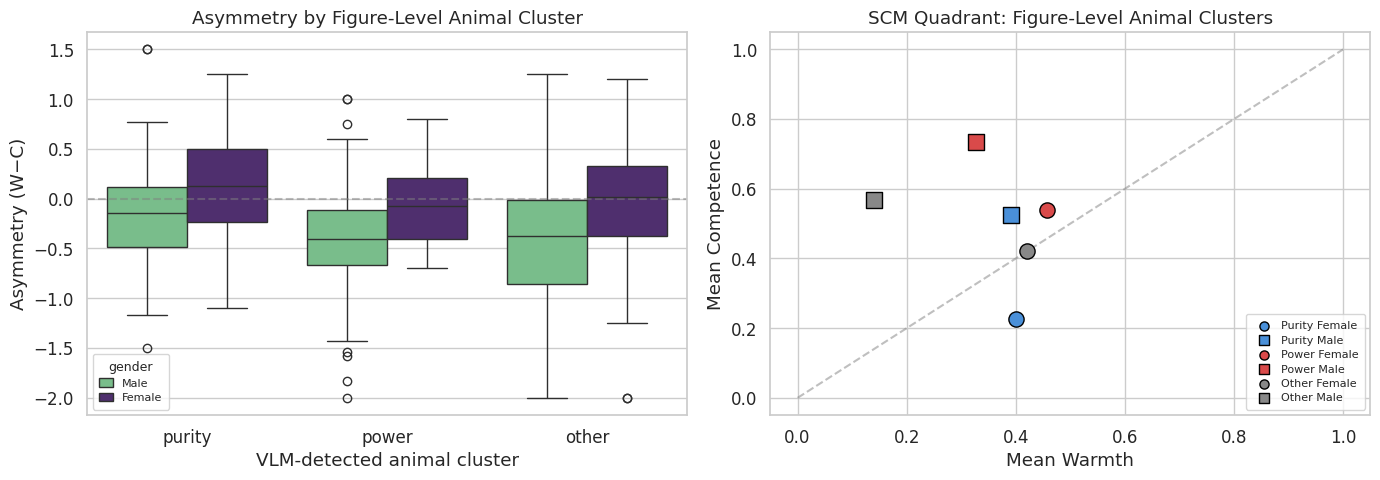

In [40]:
# ── 10e. Visualization: asymmetry by VLM cluster × gender (figures with mentions only) ──

plot_clusters = ['purity', 'power', 'other']
vlm_plot = vlm_figures[vlm_figures['vlm_cluster'].isin(plot_clusters)].copy()

if len(vlm_plot) > 30:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ── Left panel: boxplot of asymmetry by cluster × gender ──
    sns.boxplot(
        data=vlm_plot,
        x='vlm_cluster',
        y='asymmetry',
        hue='gender',
        palette=COLORS,
        order=plot_clusters,
        ax=axes[0]
    )
    
    axes[0].set_title('Asymmetry by Figure-Level Animal Cluster')
    axes[0].set_xlabel('VLM-detected animal cluster')
    axes[0].set_ylabel('Asymmetry (W−C)')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Smaller legend on the left
    axes[0].legend(
        title='gender',
        fontsize=8,
        title_fontsize=9,
        loc='lower left',
        frameon=True,
        handlelength=1.2,
        handleheight=0.8,
        borderpad=0.6,
        labelspacing=0.4
    )
    
    # ── Right panel: SCM quadrant scatter by cluster × gender ──
    for cluster in plot_clusters:
        for gender, marker in [('Female', 'o'), ('Male', 's')]:
            sub = vlm_plot[
                (vlm_plot['vlm_cluster'] == cluster) &
                (vlm_plot['gender'] == gender)
            ]
            if len(sub) > 5:
                axes[1].scatter(
                    sub['dirmean_Warmth'].mean(),
                    sub['dirmean_Competence'].mean(),
                    color=CLU_COLORS[cluster],
                    marker=marker,
                    s=120,                 # plot marker size
                    edgecolors='black',
                    linewidths=1,
                    label=f"{cluster.title()} {gender}",
                    zorder=5
                )
    
    axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
    axes[1].set_xlabel('Mean Warmth')
    axes[1].set_ylabel('Mean Competence')
    axes[1].set_title('SCM Quadrant: Figure-Level Animal Clusters')
    
    # Smaller legend markers on the right so they do not overlap
    axes[1].legend(
        fontsize=8,
        loc='lower right',
        frameon=True,
        markerscale=0.6,
        labelspacing=0.4,
        borderpad=0.6,
        handletextpad=0.5
    )
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'h3_vlm_relational_robustness.png', dpi=DPI, bbox_inches='tight')
    plt.show()
else:
    print(f"Insufficient data for plot (n={len(vlm_plot)})")